## Import Libraries

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [43]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [45]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [48]:
df.shape

(7043, 21)

In [49]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## Check Exact Column name

In [3]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Check Null Values

In [38]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Check duplicate Values

In [39]:
df.duplicated().sum()

np.int64(0)

## Convert into numeric

In [55]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [53]:
df.drop("customerID", axis =1, inplace = True)

## Handle Categorical Variables

In [8]:
df=pd.get_dummies(df, drop_first = True)

In [26]:
df.describe()


,seniorcitizen,tenure,monthlycharges,totalcharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [41]:
df.columns = df.columns.str.strip().str.replace(" ", "").str.lower()
print(df.columns.tolist())


['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn']


## Basic Statistics

In [42]:
df['tenure'].median()
df['monthlycharges'].mean()
df['churn_yes'].value_counts()

KeyError: 'churn_yes'

## Download Cleaned dataset

In [64]:
df.to_csv("cleaned_telco.csv", index=False)

## Overall Customer Churn

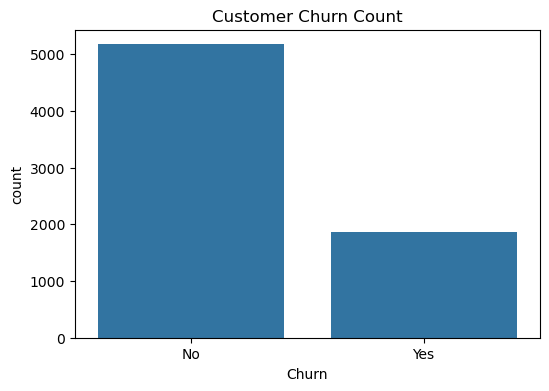

In [65]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Count")
plt.show()

## Gender vs Churn

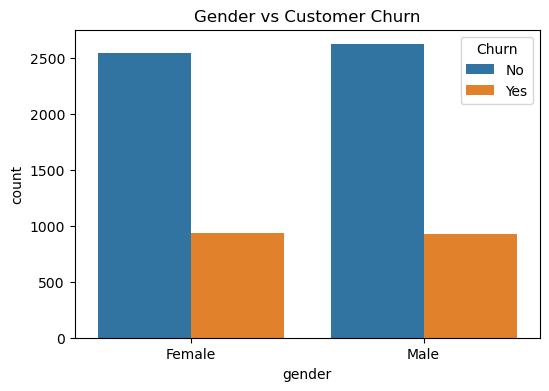

In [62]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="Churn", data=df)
plt.title("Gender vs Customer Churn")
plt.show()

## Senior Citizen vs Churn

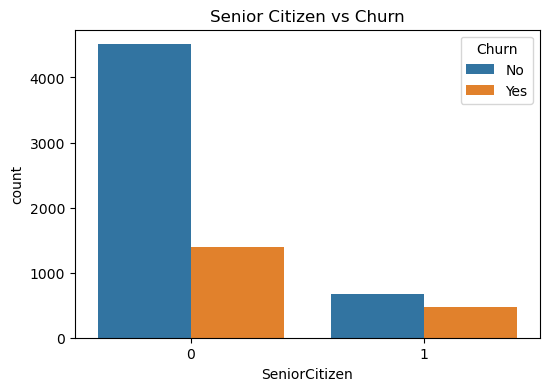

In [67]:
plt.figure(figsize=(6,4))
sns.countplot(x="SeniorCitizen", hue="Churn", data=df)
plt.title("Senior Citizen vs Churn")
plt.show()

## Contract Type vs Churn

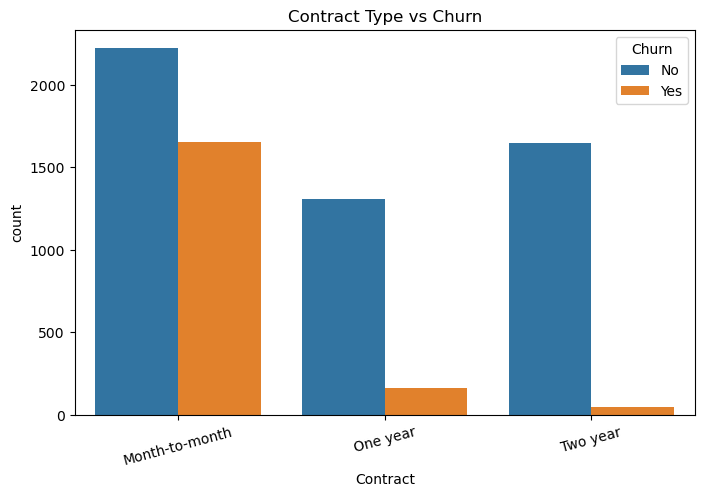

In [69]:
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()

## Internet Service vs Churn

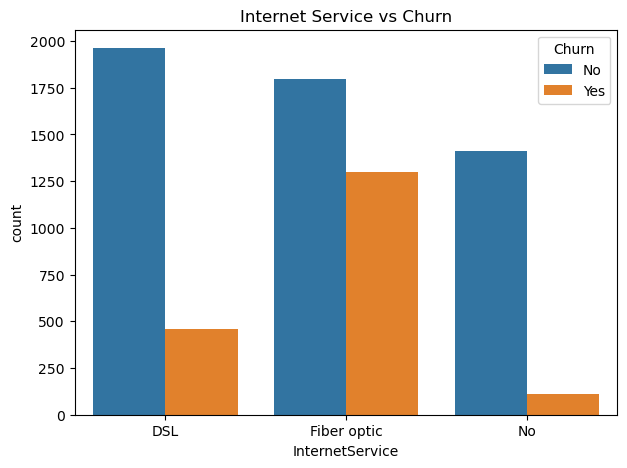

In [73]:
plt.figure(figsize=(7,5))
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Internet Service vs Churn")
plt.show()

## Payment Method vs Churn

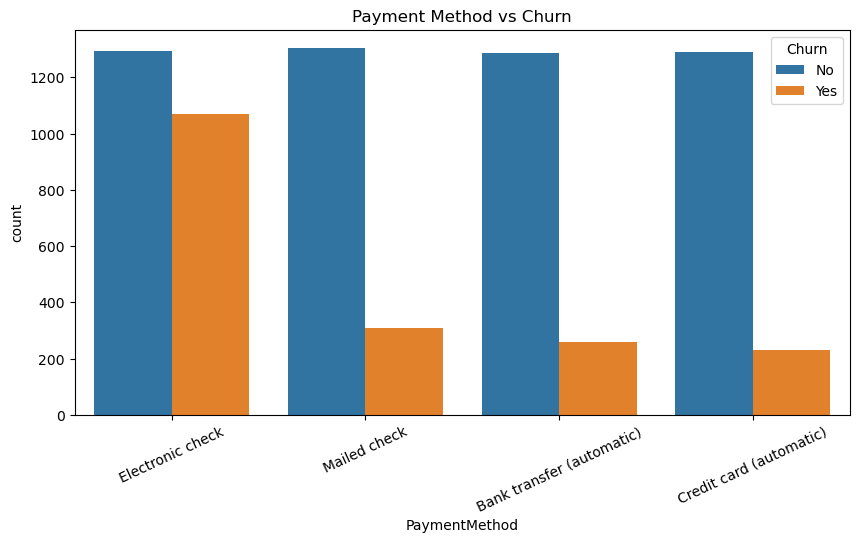

In [74]:
plt.figure(figsize=(10,5))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.xticks(rotation=25)
plt.title("Payment Method vs Churn")
plt.show()

## Monthly Charges Distribution

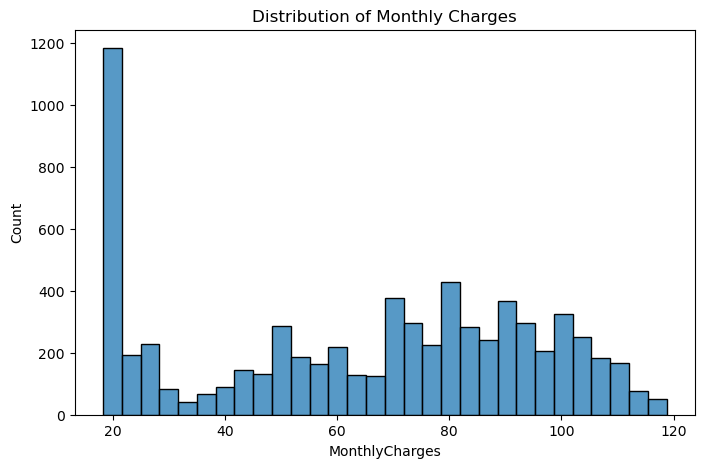

In [75]:
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"], bins=30)
plt.title("Distribution of Monthly Charges")
plt.show()

## Tenure Distribution

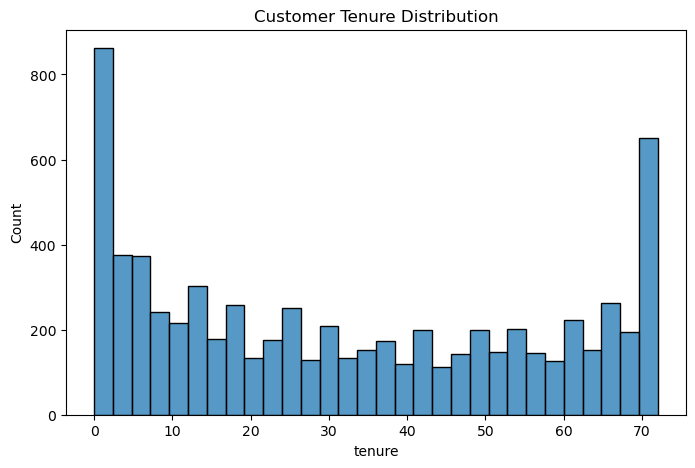

In [76]:
plt.figure(figsize=(8,5))
sns.histplot(df["tenure"], bins=30)
plt.title("Customer Tenure Distribution")
plt.show()

## Monthly Charges vs Churn

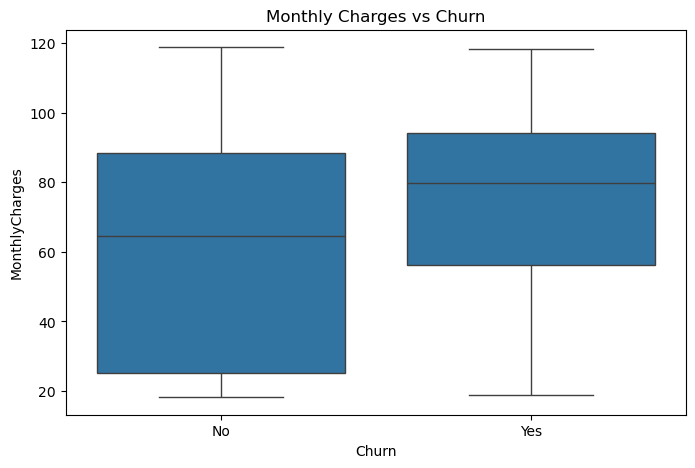

In [77]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()


## Tenure vs Churn

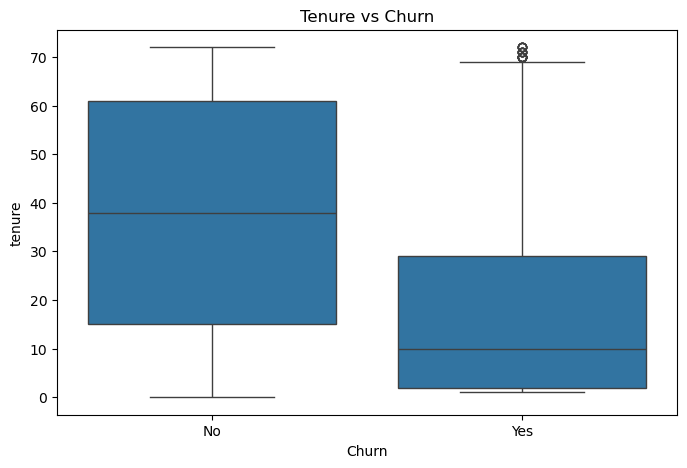

In [78]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

## Correlation Heatmap

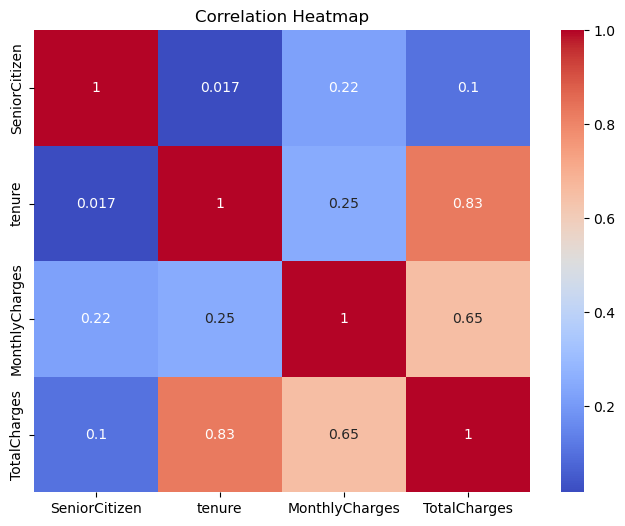

In [79]:
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=["int64","float64"])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Churn Percentage

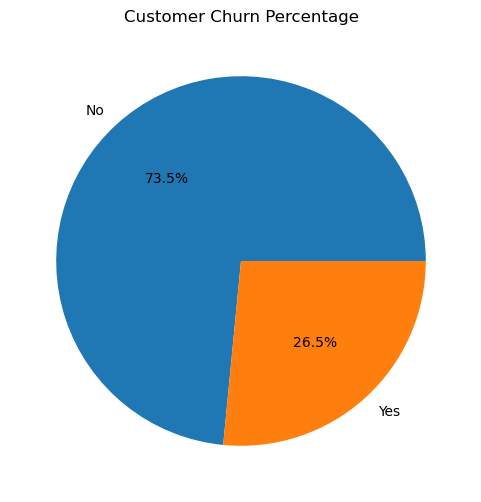

In [81]:
df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)
plt.ylabel("")
plt.title("Customer Churn Percentage")
plt.show()

##  Monthly Charges By Contract

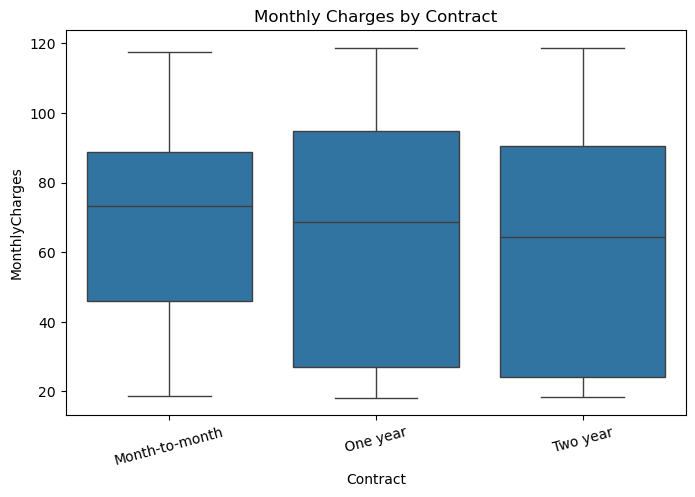

In [82]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Contract", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Contract")
plt.xticks(rotation=15)
plt.show()

## Total Charges vs Churn

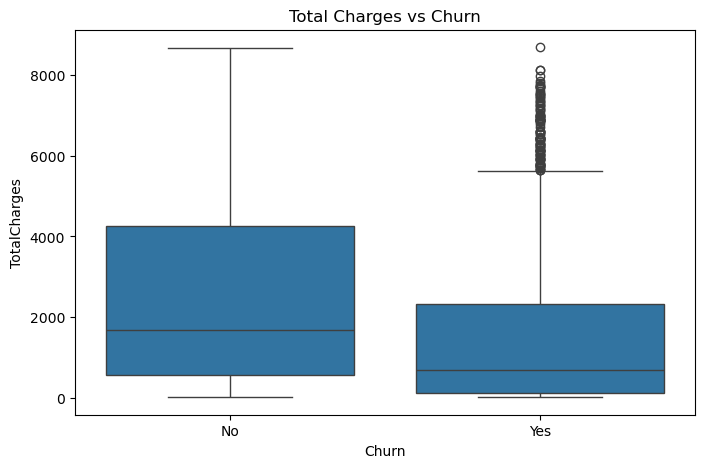

In [83]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="TotalCharges", data=df)
plt.title("Total Charges vs Churn")
plt.show()

## Tenure vs Monthly Charges

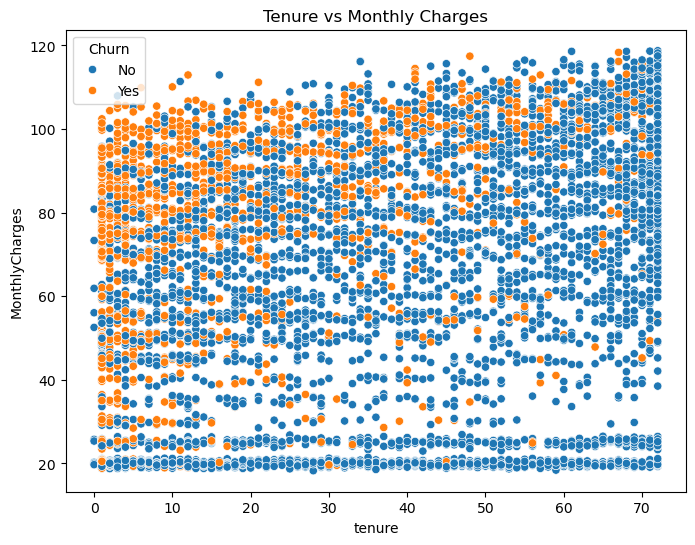

In [84]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="tenure",
    y="MonthlyCharges",
    hue="Churn",
    data=df
)
plt.title("Tenure vs Monthly Charges")
plt.show()

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [87]:
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    if df_encoded[col].dtype == "object":
        df_encoded[col] = le.fit_transform(df_encoded[col])
df_encoded.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [88]:
y= df_encoded["Churn"]
x=df_encoded.drop("Churn", axis=1)

In [92]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.20, random_state=42)
print(x_train.shape)
print(x_test.shape)

(5634, 19)
(1409, 19)


In [95]:
lr_pred = lr.predict(x_test)

In [100]:
from sklearn.metrics import accuracy_score
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.815471965933286


In [103]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

## Prediction

In [104]:
dt_pred = dt.predict(x_test)

## Accuracy

In [105]:
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.7253371185237757


## Random Forest

In [107]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

## Prediction

In [109]:
rf_pred =rf.predict(x_test)

## Accuracy

In [112]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7955997161107168


## Compare Accuracy

In [111]:
print("Logistic Regression :", accuracy_score(y_test, lr_pred))
print("Decision Tree       :", accuracy_score(y_test, dt_pred))
print("Random Forest       :", accuracy_score(y_test, rf_pred))

Logistic Regression : 0.815471965933286
Decision Tree       : 0.7253371185237757
Random Forest       : 0.7955997161107168


In [116]:
pip install shap

## Import SHAP

In [117]:
import shap

## Create SHAP Explainer

In [115]:
explainer = shap.TreeExplainer(rf)

## Calculate SHAP Values

In [119]:
shap_values = explainer.shap_values(x_test)

## Display Feature Importance

In [ ]:
shap.summary_plot(shap_values[:, :, 1], X_test)
shap.summary_plot(shap_values[1], X_test)

In [ ]:
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar")
shap.summary_plot(shap_values[1], X_test, plot_type="bar")

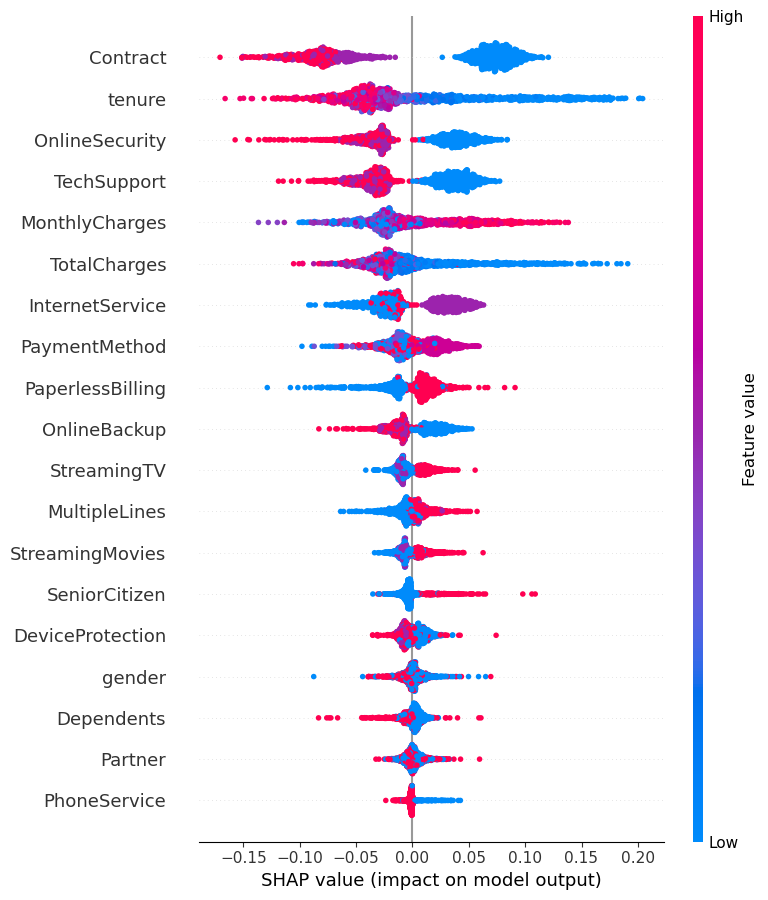

In [123]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(x_test)

shap.summary_plot(shap_values[:, :, 1], x_test)

In [ ]:
import pandas as pd
import numpy as np

importance = np.abs(shap_values[:, :, 1]).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": x_test.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))